# Subjectivity bias in digital media: a causal driver of virality or a reflection of popular content topics ?

authors: Benjamin Cerf, Céline Ferbach, Carla Lucas, Elyan Rougon, Chiara Tagiullo


## 1. Introduction


### Setup

In [5]:
# libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy as sp
import seaborn as sns

from pathlib import Path

# seed
SEED = 42
rng = np.random.default_rng(SEED)

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 120)

In [2]:
# load data
DATA_PATH = Path("data/OnlineNewsPopularity.csv")
df = pd.read_csv(DATA_PATH)

display(df.head(3))
display(df.tail(3))

# column cleanup
df.columns = df.columns.str.strip()

# check duplicates or missing
display(df.info())
print("Duplicate rows:", df.duplicated().sum())

,url,timedelta,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,num_videos,average_token_length,num_keywords,data_channel_is_lifestyle,data_channel_is_entertainment,data_channel_is_bus,data_channel_is_socmed,data_channel_is_tech,data_channel_is_world,kw_min_min,kw_max_min,kw_avg_min,kw_min_max,kw_max_max,kw_avg_max,kw_min_avg,kw_max_avg,kw_avg_avg,self_reference_min_shares,self_reference_max_shares,self_reference_avg_sharess,weekday_is_monday,weekday_is_tuesday,weekday_is_wednesday,weekday_is_thursday,weekday_is_friday,weekday_is_saturday,weekday_is_sunday,is_weekend,LDA_00,LDA_01,LDA_02,LDA_03,LDA_04,global_subjectivity,global_sentiment_polarity,global_rate_positive_words,global_rate_negative_words,rate_positive_words,rate_negative_words,avg_positive_polarity,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,shares
0,http://mashable.com/2013/01/07/amazon-instant-...,731.0,12.0,219.0,0.663594,1.0,0.815385,4.0,2.0,1.0,0.0,4.680365,5.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,496.0,496.0,496.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.500331,0.378279,0.040005,0.041263,0.040123,0.521617,0.092562,0.045662,0.013699,0.769231,0.230769,0.378636,0.100000,0.7,-0.350000,-0.600,-0.200000,0.5,-0.1875,0.0,0.1875,593
1,http://mashable.com/2013/01/07/ap-samsung-spon...,731.0,9.0,255.0,0.604743,1.0,0.791946,3.0,1.0,1.0,0.0,4.913725,4.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.799756,0.050047,0.050096,0.050101,0.050001,0.341246,0.148948,0.043137,0.015686,0.733333,0.266667,0.286915,0.033333,0.7,-0.118750,-0.125,-0.100000,0.0,0.0000,0.5,0.0000,711
2,http://mashable.com/2013/01/07/apple-40-billio...,731.0,9.0,211.0,0.575130,1.0,0.663866,3.0,1.0,1.0,0.0,4.393365,6.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,918.0,918.0,918.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.217792,0.033334,0.033351,0.033334,0.682188,0.702222,0.323333,0.056872,0.009479,0.857143,0.142857,0.495833,0.100000,1.0,-0.466667,-0.800,-0.133333,0.0,0.0000,0.5,0.0000,1500


,url,timedelta,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,num_videos,average_token_length,num_keywords,data_channel_is_lifestyle,data_channel_is_entertainment,data_channel_is_bus,data_channel_is_socmed,data_channel_is_tech,data_channel_is_world,kw_min_min,kw_max_min,kw_avg_min,kw_min_max,kw_max_max,kw_avg_max,kw_min_avg,kw_max_avg,kw_avg_avg,self_reference_min_shares,self_reference_max_shares,self_reference_avg_sharess,weekday_is_monday,weekday_is_tuesday,weekday_is_wednesday,weekday_is_thursday,weekday_is_friday,weekday_is_saturday,weekday_is_sunday,is_weekend,LDA_00,LDA_01,LDA_02,LDA_03,LDA_04,global_subjectivity,global_sentiment_polarity,global_rate_positive_words,global_rate_negative_words,rate_positive_words,rate_negative_words,avg_positive_polarity,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,shares
39641,http://mashable.com/2014/12/27/son-pays-off-mo...,8.0,10.0,442.0,0.516355,1.0,0.644128,24.0,1.0,12.0,1.0,5.076923,8.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,691.0,168.25,6200.0,843300.0,295850.0,1753.882353,6880.687034,4206.439195,1400.0,1400.0,1400.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.159004,0.025025,0.025207,0.643794,0.146970,0.510296,0.024609,0.033937,0.024887,0.576923,0.423077,0.307273,0.136364,0.5,-0.356439,-0.8,-0.166667,0.454545,0.136364,0.045455,0.136364,1900
39642,http://mashable.com/2014/12/27/ukraine-blasts/,8.0,6.0,682.0,0.539493,1.0,0.692661,10.0,1.0,1.0,0.0,4.975073,5.0,0.0,0.0,0.0,0.0,0.0,1.0,-1.0,0.0,-1.00,0.0,843300.0,254600.0,0.000000,3384.316871,1777.895883,452.0,452.0,452.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.040004,0.040003,0.839987,0.040002,0.040004,0.358578,-0.008066,0.020528,0.023460,0.466667,0.533333,0.236851,0.062500,0.5,-0.205246,-0.5,-0.012500,0.000000,0.000000,0.500000,0.000000,1100
39643,http://mashable.com/2014/12/27/youtube-channel...,8.0,10.0,157.0,0.701987,1.0,0.846154,1.0,1.0,0.0,2.0,4.471338,4.0,0.0,1.0,0.0,0.0,0.0,0.0,-1.0,97.0,23.50,205600.0,843300.0,366200.0,3035.080555,3613.512953,3296.909481,2100.0,2100.0,2100.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.050001,0.799339,0.050000,0.050659,0.050001,0.517893,0.104892,0.063694,0.012739,0.833333,0.166667,0.247338,0.100000,0.5,-0.200000,-0.2,-0.200000,0.333333,0.250000,0.166667,0.250000,1300


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39644 entries, 0 to 39643
Data columns (total 61 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   url                            39644 non-null  object 
 1   timedelta                      39644 non-null  float64
 2   n_tokens_title                 39644 non-null  float64
 3   n_tokens_content               39644 non-null  float64
 4   n_unique_tokens                39644 non-null  float64
 5   n_non_stop_words               39644 non-null  float64
 6   n_non_stop_unique_tokens       39644 non-null  float64
 7   num_hrefs                      39644 non-null  float64
 8   num_self_hrefs                 39644 non-null  float64
 9   num_imgs                       39644 non-null  float64
 10  num_videos                     39644 non-null  float64
 11  average_token_length           39644 non-null  float64
 12  num_keywords                   39644 non-null 

None

Duplicate rows: 0


,count,mean,std,min,25%,50%,75%,max
timedelta,39644.0,354.530471,214.163767,8.00000,164.000000,339.000000,542.000000,731.000000
n_tokens_title,39644.0,10.398749,2.114037,2.00000,9.000000,10.000000,12.000000,23.000000
n_tokens_content,39644.0,546.514731,471.107508,0.00000,246.000000,409.000000,716.000000,8474.000000
n_unique_tokens,39644.0,0.548216,3.520708,0.00000,0.470870,0.539226,0.608696,701.000000
n_non_stop_words,39644.0,0.996469,5.231231,0.00000,1.000000,1.000000,1.000000,1042.000000
n_non_stop_unique_tokens,39644.0,0.689175,3.264816,0.00000,0.625739,0.690476,0.754630,650.000000
num_hrefs,39644.0,10.883690,11.332017,0.00000,4.000000,8.000000,14.000000,304.000000
num_self_hrefs,39644.0,3.293638,3.855141,0.00000,1.000000,3.000000,4.000000,116.000000
num_imgs,39644.0,4.544143,8.309434,0.00000,1.000000,1.000000,4.000000,128.000000
num_videos,39644.0,1.249874,4.107855,0.00000,0.000000,0.000000,1.000000,91.000000


Numeric columns: 60


### PICO formulation

We aim to investigate whether the subjectivity of an online news articles affects its popularity, measured by the number of times the article was shared on social media. Since subjectivity is not randomly assigned but determined by editorial and writing choices, this is a causal inference problem.

- Population: 39,644 online news articles published on [Mashable](https://mashable.com/), as recorded in the UCI Online News Popularity dataset available [here](https://archive.ics.uci.edu/dataset/332/online+news+popularity). Each observation corresponds to one article, described by content-based, sentiment-based, and metadata features.
  
- Intervention: the treatment variable is the subjectivity of the article. Subjectivity is measured by variables such as `global_subjectivity` or `title_subjectivity`, which range between 0 (fully objective) and 1 (fully subjective).

- Control: the control group consists of articles with lower subjectivity.
  
- Outcome: the outcome variable is the number of social media shares (`shares`), which measures article popularity. Due to the its highly skewed distribution, we consider Y=`log_shares`.


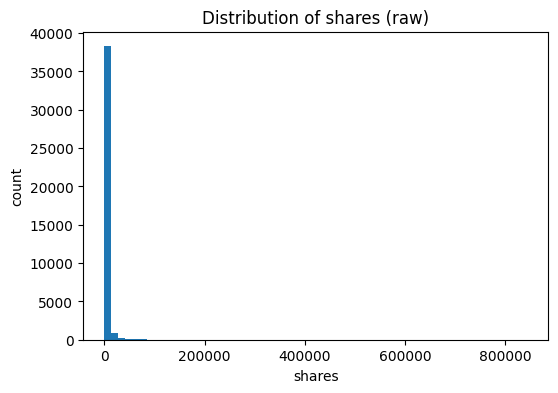

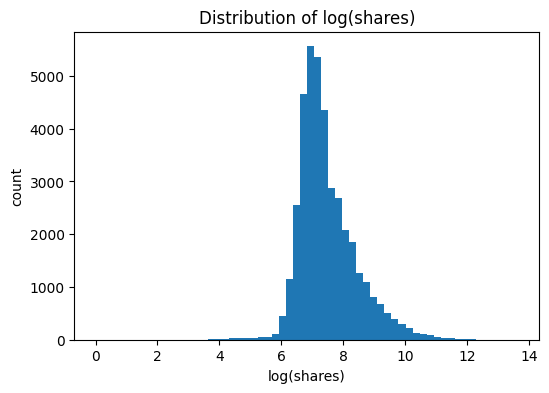

,count,mean,std,min,25%,50%,75%,max
shares,39644.0,3395.380184,11626.950749,1.0,946.000000,1400.000000,2800.000000,843300.000000
log_shares,39644.0,7.474855,0.930486,0.0,6.852243,7.244228,7.937375,13.645078


In [8]:
# outcome variable
y = "shares"

# outcome variable
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(df[y], bins=60)
ax.set_title("Distribution of shares (raw)")
ax.set_xlabel("shares")
ax.set_ylabel("count")
plt.show()

# use log transform of shares, no share is 0
df["log_shares"] = np.log(df[y])

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(df["log_shares"], bins=60)
ax.set_title("Distribution of log(shares)")
ax.set_xlabel("log(shares)")
ax.set_ylabel("count")
plt.show()

display(df[[y, "log_shares"]].describe().T)

y = "log_shares"


## 2. Exploratory Data Analysis 

### Description


In [ ]:
# we have categorical and numerical variables
# summary statistics for numeric columns
display(df.describe(include="number").T)

# keep a list of numeric feature columns (not url)
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c not in ["log_shares"]]  # keep shares inside for some plots
print("Numeric columns:", len(num_cols))

# focus on key variables: y=log(shares) and subjectivity (+title_subjectivity)
key_vars = [y, "global_subjectivity", "title_subjectivity"]
key_vars = [c for c in key_vars if c in df.columns]

# summary statistics
display(df[key_vars].describe().T)

# Distribution of global subjectivity
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(df["global_subjectivity"], bins=30)
ax.set_title("Distribution of Global Subjectivity")
ax.set_xlabel("global_subjectivity")
ax.set_ylabel("count")
plt.show()

# and title
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(df["title_subjectivity"], bins=30)
ax.set_title("Distribution of Title Subjectivity")
ax.set_xlabel("title_subjectivity")
ax.set_ylabel("count")
plt.show()

# many are deemed perfectly objective

### Association

,global_subjectivity,title_subjectivity,log_shares
global_subjectivity,1.000000,0.114123,0.075145
title_subjectivity,0.114123,1.000000,0.052714
log_shares,0.075145,0.052714,1.000000


Correlation between global_subjectivity and log_shares: 0.07514462643719126


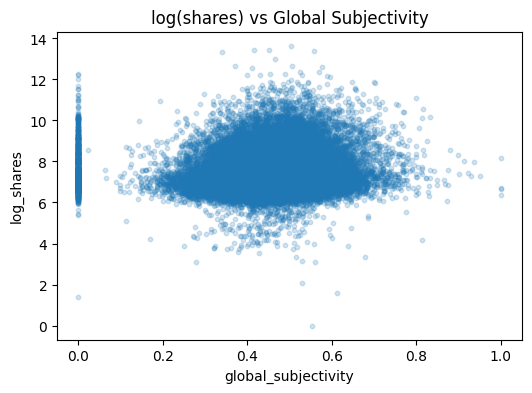

In [22]:
# correlation between subjectivity and y = shares
corr_matrix = df[["global_subjectivity", "title_subjectivity", y]].corr()
display(corr_matrix)

print("Correlation between global_subjectivity and log_shares:",
      corr_matrix.loc["global_subjectivity", y])

# scatter plot: global_subjectivity vs log_shares
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(df["global_subjectivity"], df[y], 
           alpha=0.2, s=10)
ax.set_title("log(shares) vs Global Subjectivity")
ax.set_xlabel("global_subjectivity")
ax.set_ylabel("log_shares")
plt.show()

# define a simple treatment: High vs Low Subjectivity (median split)
median_subj = df["global_subjectivity"].median()
df["high_subjectivity"] = (df["global_subjectivity"] > median_subj).astype(int)
print("Median subjectivity:", median_subj)
# new categorical variable: high_subjectivity

# group comparison (mean outcome)
group_means = df.groupby("high_subjectivity")[y].mean()
display(group_means)

print("Difference in mean log_shares (High - Low):",
      group_means.loc[1] - group_means.loc[0])
# boxplot comparison

fig, ax = plt.subplots(figsize=(6, 4))
ax.boxplot(
    [df.loc[df["high_subjectivity"] == 0, y],
     df.loc[df["high_subjectivity"] == 1, y]],
    labels=["Low Subjectivity", "High Subjectivity"],
    showfliers=False
)
ax.set_title("log(shares) by Subjectivity Group")
ax.set_ylabel("log_shares")
plt.show()

### Visualization

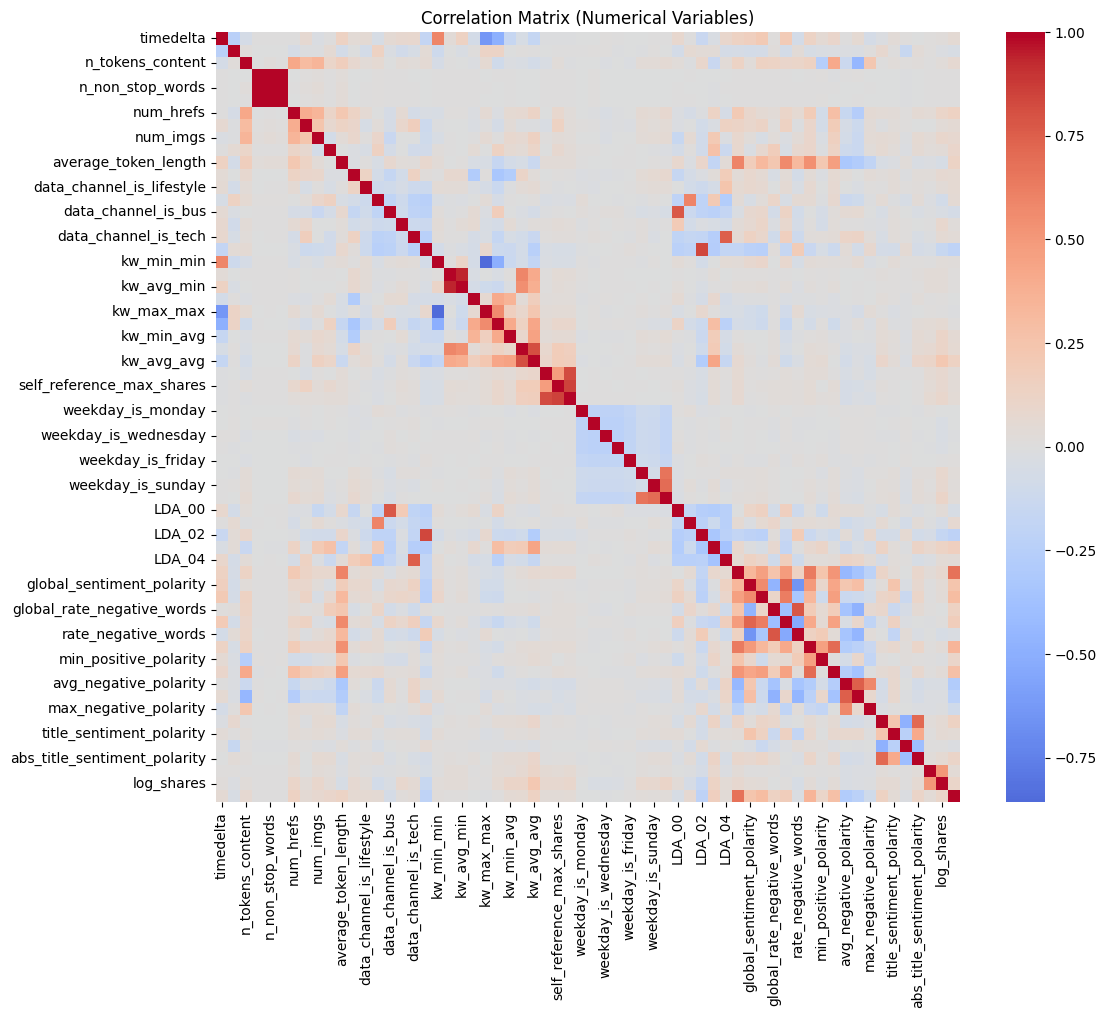

log_shares                    1.000000
shares                        0.509906
kw_avg_avg                    0.221720
LDA_03                        0.125962
is_weekend                    0.114387
kw_max_avg                    0.109292
kw_min_avg                    0.108823
num_hrefs                     0.105105
high_subjectivity             0.100694
num_imgs                      0.091518
self_reference_avg_sharess    0.087217
data_channel_is_socmed        0.081106
weekday_is_saturday           0.079147
self_reference_max_shares     0.077427
weekday_is_sunday             0.076975
Name: log_shares, dtype: float64

min_positive_polarity           -0.010767
max_negative_polarity           -0.014200
n_tokens_title                  -0.019030
min_negative_polarity           -0.022738
weekday_is_thursday             -0.028171
data_channel_is_bus             -0.030599
weekday_is_tuesday              -0.031073
avg_negative_polarity           -0.034310
weekday_is_wednesday            -0.036590
average_token_length            -0.045283
rate_negative_words             -0.048171
LDA_01                          -0.052993
data_channel_is_entertainment   -0.082504
data_channel_is_world           -0.151651
LDA_02                          -0.165034
Name: log_shares, dtype: float64

global_subjectivity           1.000000
high_subjectivity             0.679017
avg_positive_polarity         0.631749
average_token_length          0.597629
max_positive_polarity         0.518773
rate_positive_words           0.487481
global_rate_positive_words    0.467063
global_sentiment_polarity     0.339436
global_rate_negative_words    0.253181
min_positive_polarity         0.243984
Name: global_subjectivity, dtype: float64

kw_min_max              -0.018202
data_channel_is_bus     -0.028078
kw_max_max              -0.040859
n_tokens_title          -0.056804
kw_avg_max              -0.064106
LDA_02                  -0.178582
data_channel_is_world   -0.179194
max_negative_polarity   -0.223191
min_negative_polarity   -0.350070
avg_negative_polarity   -0.443187
Name: global_subjectivity, dtype: float64

In [31]:
# correlation matrix (numerical variables only)
corr_matrix = df.select_dtypes(include=[np.number]).corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix,
            cmap="coolwarm",
            center=0,
            square=False,
            cbar=True)
plt.title("Correlation Matrix (Numerical Variables)")
plt.show()
# a bit dense

# some correlations with y = log_shares
target_corr = corr_matrix["log_shares"].sort_values(ascending=False)
display(target_corr.head(15))
display(target_corr.tail(15))

# with subjectivity
subj_corr = corr_matrix["global_subjectivity"].sort_values(ascending=False)
display(subj_corr.head(10))
display(subj_corr.tail(10))

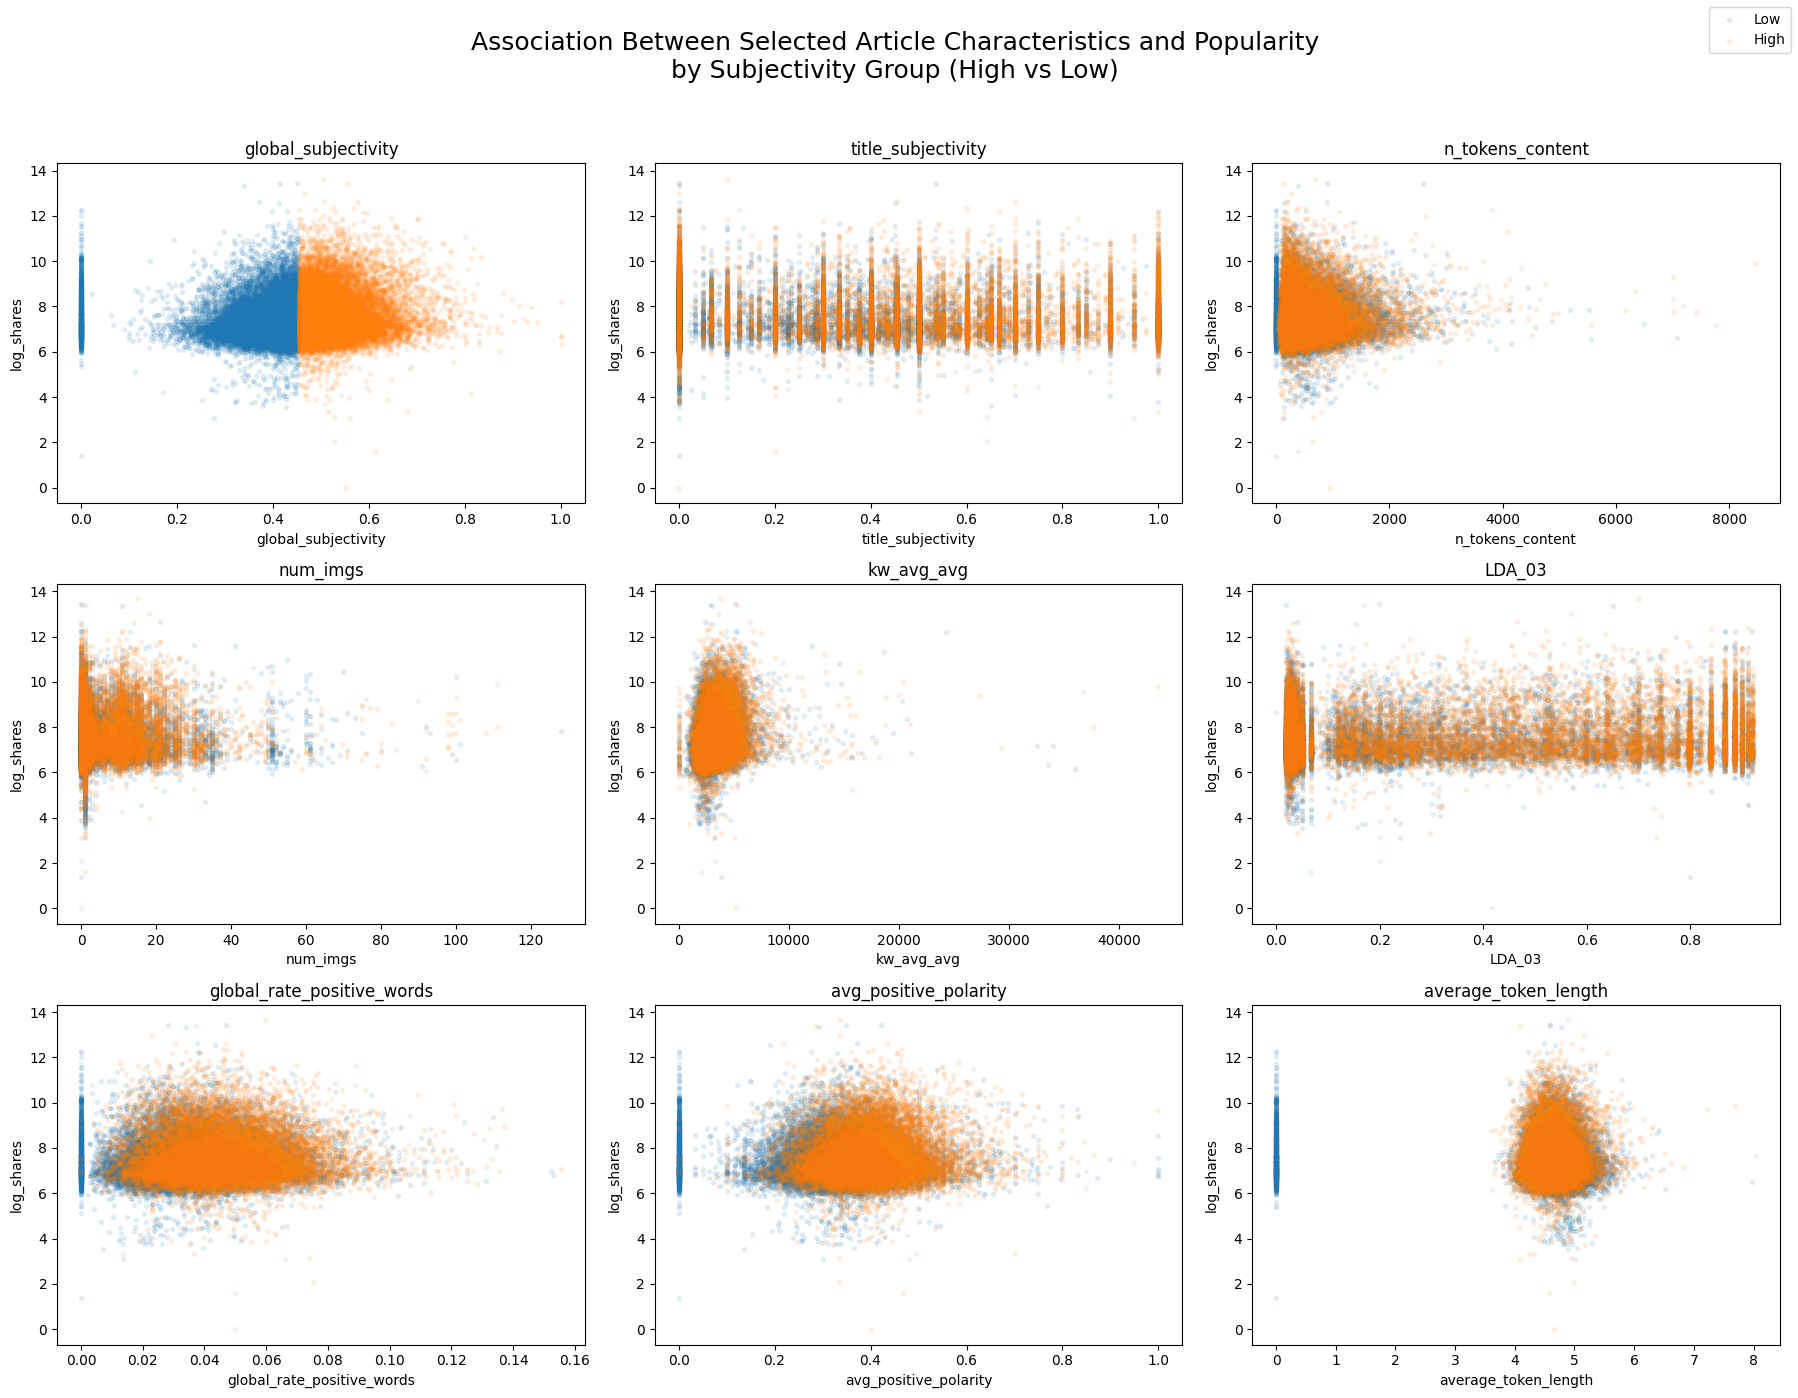

In [37]:
# scatter plots vs log(shares) colored by simple subjectivity treatment group
interesting_vars = [
    "global_subjectivity",
    "title_subjectivity",
    "n_tokens_content",
    "num_imgs",
    "kw_avg_avg",
    "LDA_03",
    "global_rate_positive_words",
    "avg_positive_polarity",
    "average_token_length"
]

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

for i, var in enumerate(interesting_vars):
    
    ax = axes[i]
    
    # Low subjectivity
    x_low = df.loc[df["high_subjectivity"] == 0, var]
    y_low = df.loc[df["high_subjectivity"] == 0, "log_shares"]
    
    ax.scatter(x_low, y_low, alpha=0.1, s=8, label="Low")
    
    # High subjectivity
    x_high = df.loc[df["high_subjectivity"] == 1, var]
    y_high = df.loc[df["high_subjectivity"] == 1, "log_shares"]
    
    ax.scatter(x_high, y_high, alpha=0.1, s=8, label="High")
    
    ax.set_title(var)
    ax.set_xlabel(var)
    ax.set_ylabel("log_shares")

# common title
fig.suptitle(
    "Association Between Selected Article Characteristics and Popularity\n"
    "by Subjectivity Group (High vs Low)",
    fontsize=18
)

# legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


## 3. Identification with causal graph and choice of covariates to include



## 4. Discussion on the assumptions chosen for identification of the effect



## 5. Estimation with an appropriate causal estimator 
(double post lasso, double machine learning, generic machine learning, inverse propensity score, augmented propensity score) and regressor (lasso, ridge, random forest, boosting). It is not expected that you test or use every method.



## 6. Parameter/model selection for the statistical estimator (cross-validation)



## 7. Develop and implement one of the following aspect (one choice among three): 
- Compare different statistical estimators or causal models for you estimates of the population effect. 
- Heterogeneous treatment effects: study the effect of the treatment on different subgroups of the population 
- Policy learning : What would be the best assignment policy ? Take inspiration from the doubleml case study.



## 8. Sensitivity analysis: placebo check, different covariate sets



## 9. Conclusion and discussion of the results
